In [1]:
import bw2data, bw2io, bw2calc
import numpy as np
import os
import re
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

### static LCI +  three GWP
- GWP100
- pGWP-fixed vs. dp-CO2 

In [2]:
wind  = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/wind_CN_US_staticLCI_threeGWP100.xlsx")
#hydro = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/hydro_run-of-river_CN_US_staticLCI_threeGWP100.xlsx")
hydro = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/hydro_reservoir_CN-asRoW_US-asQC_staticLCI_threeGWP100.xlsx")
pv    = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/PV_CN_US_staticLCI_threeGWP100.xlsx")

In [3]:
def tidy(df, tech_label):
    parts = df["Activity"].str.split(", ", expand=True)
    out = df.copy()
    out["Technology"] = tech_label
    out["Country"]    = parts[3].str[:2]
    out["SSP"]        = parts[4]
    out["Year"]       = parts[5].astype(int)
    return out[["Technology", "Country", "SSP", "Year",
                "gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]]

all_df = pd.concat(
    [tidy(wind,  "Wind"),
     tidy(hydro, "Hydro"),
     tidy(pv,    "PV")],
    ignore_index=True,
)

# Keep only 2030 & 2050
df = all_df[all_df["Year"].isin([2030, 2050])].copy()

# long format over metrics
metric_cols = ["gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]
df_long = df.melt(
    id_vars=["Technology", "Country", "SSP", "Year"],
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score",
)

df_long


,Technology,Country,SSP,Year,Metric,Score
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036905
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017832
2,Wind,CN,SSP2-M,2030,gwp100,0.037723
3,Wind,CN,SSP2-M,2050,gwp100,0.031185
4,Wind,CN,SSP5-H,2030,gwp100,0.038734
...,...,...,...,...,...,...
103,PV,US,SSP1-VLLO,2050,pGWP100_dpCO2,0.006184
104,PV,US,SSP2-M,2030,pGWP100_dpCO2,0.020048
105,PV,US,SSP2-M,2050,pGWP100_dpCO2,0.012654
106,PV,US,SSP5-H,2030,pGWP100_dpCO2,0.020952


#### adding:  dpLCI + pGWP-fixedCO2

In [4]:

#with open("dp-LCI_output/dpLCI_pGWP-fixed_pickle/hydro_dp_results_MY2030_2050.pkl","rb") as f:
with open("dp-LCI_output/dpLCI_pGWP-fixed_pickle/hydro_v2_reservoir_dp_region_harmonized.pkl","rb") as f:
    hydro_dp = pickle.load(f)    

with open("dp-LCI_output/dpLCI_pGWP-fixed_pickle/PV_dp_results_MY2030_2050.pkl","rb") as f:
    pv_dp = pickle.load(f)

with open("dp-LCI_output/dpLCI_pGWP-fixed_pickle/wind_dp_results_allMY.pkl","rb") as f:
    wind_dp = pickle.load(f)


# extract the new dp metrics and produce a DataFrame with exact columns:
# Activity, Technology, Country, SSP, Year, Metric, Score
# ONLY WANNA 2030 & 2050 as two MY:: 

def extract_from_dp_dict(dp_dict):
    rows = []

    # map activity string tech → tidy Technology label
    tech_map = {
        "wind": "Wind",
        "PV": "PV",
        "hydro": "Hydro",
    }

    #####   we need to convert all US-xx / CN-xx country code to just US/CN 
    def collapse_country(region):
        """Collapse ecoinvent/IAM region to CN or US."""
        if region.startswith("US"):
            return "US"
        if region.startswith("CN"):
            return "CN"
        # if you ever have other regions, either return as-is or map them too
        return region

    for act, metrics in dp_dict.items():
        parts = act.split(", ")

        raw_tech = parts[1]              # 'wind' / 'photovoltaic' / 'hydro'
        if raw_tech not in tech_map:
            print(row_tech)
            continue                     # skip unexpected techs

        tech        = tech_map[raw_tech]
        region      = parts[3]           # e.g. 'US-TRE', 'CN-NM'
        country     = collapse_country(region)
        ssp         = parts[4]
        year        = int(parts[5])

        # keep only 2030 & 2050
        if year not in (2030, 2050):
            continue

        for metric_name, value in metrics.items():
            rows.append(
                {
                    "Technology": tech,
                    "Country": country,   # NOW only 'US' or 'CN'
                    "SSP": ssp,
                    "Year": year,
                    "Metric": metric_name,
                    "Score": float(value),
                }
            )

    return pd.DataFrame(rows)



df_hydro_dp = extract_from_dp_dict(hydro_dp)
df_pv_dp    = extract_from_dp_dict(pv_dp)
df_wind_dp  = extract_from_dp_dict(wind_dp)

df_dp = pd.concat([df_hydro_dp, df_pv_dp, df_wind_dp], ignore_index=True)
print(len(df_dp)) # should be 72, so that 72/2(new metric) == 36
df_dp


72


,Technology,Country,SSP,Year,Metric,Score
0,Hydro,CN,SSP1-VLLO,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.053979
1,Hydro,CN,SSP1-VLLO,2050,"full dp-LCI, pGWP100-fixedCO2",0.057714
2,Hydro,US,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017909
3,Hydro,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.017975
4,Hydro,US,SSP2-M,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017505
...,...,...,...,...,...,...
67,Wind,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.024138
68,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017229
69,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.021193
70,Wind,CN,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.041520


In [5]:
#df_dp 
df_full = pd.concat([df_long, df_dp], ignore_index=True)
#df_full

In [6]:
# NOW recompute Rank with the two new metrics included
df_full["Rank"] = df_full.groupby(
    ["Country","SSP","Year","Metric"]
)["Score"].rank(method="dense", ascending=True)

df_full

,Technology,Country,SSP,Year,Metric,Score,Rank
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036905,2.0
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017832,2.0
2,Wind,CN,SSP2-M,2030,gwp100,0.037723,2.0
3,Wind,CN,SSP2-M,2050,gwp100,0.031185,2.0
4,Wind,CN,SSP5-H,2030,gwp100,0.038734,2.0
...,...,...,...,...,...,...,...
175,Wind,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.024138,3.0
176,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017229,3.0
177,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.021193,3.0
178,Wind,CN,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.041520,2.0


In [7]:
metric_rename = {
    "gwp100": "staticLCI + IPCC-GWP",
    "pGWP100_fixedCO2": "staticLCI + pGWP-fixedCO2",
    "pGWP100_dpCO2": "staticLCI + pGWP-dpCO2",
    "dyn FG LCI static BG p-LCI, pGWP100-fixedCO2": "dyn-FG-LCI + pGWP-fixedCO2",
    "full dp-LCI, pGWP100-fixedCO2": "full dpLCI + pGWP-fixedCO2"
}

In [8]:
df_full["Metric"] = df_full["Metric"].replace(metric_rename)

In [9]:
df_full_sorted = df_full.sort_values([ "SSP","Year", "Country", "Technology"	]) 
df_full_sorted

,Technology,Country,SSP,Year,Metric,Score,Rank
18,Hydro,CN,SSP1-VLLO,2030,staticLCI + IPCC-GWP,0.050523,3.0
54,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-fixedCO2,0.057266,3.0
90,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-dpCO2,0.050021,3.0
130,Hydro,CN,SSP1-VLLO,2030,dyn-FG-LCI + pGWP-fixedCO2,0.057266,3.0
131,Hydro,CN,SSP1-VLLO,2030,full dpLCI + pGWP-fixedCO2,0.057505,3.0
...,...,...,...,...,...,...,...
11,Wind,US,SSP5-H,2050,staticLCI + IPCC-GWP,0.019234,3.0
47,Wind,US,SSP5-H,2050,staticLCI + pGWP-fixedCO2,0.017215,3.0
83,Wind,US,SSP5-H,2050,staticLCI + pGWP-dpCO2,0.019006,3.0
168,Wind,US,SSP5-H,2050,dyn-FG-LCI + pGWP-fixedCO2,0.017215,3.0


In [10]:
df_full_sorted.to_excel("plot_rankshift_hydro_v2_reservoir.xlsx")

### updated plot, with a GAP threshold 

#### function

In [17]:
def plot_pairwise_gaps_dots(
    df_long,
    country="US",
    ssp="SSP5-H",
    year=2030,
    metric_order=None,
    metric_labels=None,
    pairs=(("PV", "Wind"), ("PV", "Hydro"), ("Wind", "Hydro")),
    gap_threshold_pct=5.0,
    figsize=(9, 4),
    size_scale=35,   # controls bubble size strength
):
    """
    Dot (bubble) plot of pairwise technology gaps across metrics.
    """

    if metric_labels is None:
        metric_labels = {m: m for m in metric_order}

    sub = df_long[
        (df_long["Country"] == country) &
        (df_long["SSP"] == ssp) &
        (df_long["Year"] == year)
    ]

    # marker & color maps (print-safe)
    marker_map = {
        "PV vs Wind": "o",
        "PV vs Hydro": "s",
        "Wind vs Hydro": "D",
    }
    color_map = {
        "PV vs Wind": "tab:blue",
        "PV vs Hydro": "tab:orange",
        "Wind vs Hydro": "tab:green",
    }

    rows = []
    for m in metric_order:
        sm = sub[sub["Metric"] == m].set_index("Technology")["Score"]
        for a, b in pairs:
            if a in sm.index and b in sm.index:
                sa, sb = float(sm.loc[a]), float(sm.loc[b])
                gap = abs(sa - sb) / max(sa, sb) * 100.0
                rows.append({
                    "Metric": m,
                    "Pair": f"{a} vs {b}",
                    "Gap_pct": gap,
                })

    dg = pd.DataFrame(rows)
    if dg.empty:
        raise ValueError("No gaps computed — check filters or Technology labels.")

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(metric_order))

    for pair in dg["Pair"].unique():
        vals = (
            dg[dg["Pair"] == pair]
            .set_index("Metric")["Gap_pct"]
            .reindex(metric_order)
        )

        sizes = size_scale * np.sqrt(vals.values)  # gentle bubble scaling

        ax.scatter(
            x,
            vals.values,
            s=sizes,
            marker=marker_map[pair],
            color=color_map[pair],
            edgecolor="black",
            linewidth=0.7,
            alpha=0.85,
            label=pair,
            zorder=5,
        )

    # threshold line
    ax.axhline(
        gap_threshold_pct,
        linestyle="--",
        linewidth=1.2,
        color="tab:red",
        alpha=0.8,
        zorder=3,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [metric_labels[m] for m in metric_order],
        rotation=20,
        ha="right",
    )

    ax.set_ylabel("Pairwise gap (%)")
    ax.set_title(f"{country}, {ssp}, {year} — pairwise technology gaps")

    ax.grid(axis="y", linestyle=":", alpha=0.35)

    ax.legend(
        ncol=3,
        loc="upper left",
        frameon=True,
        fontsize=10,
    )

    plt.tight_layout()
    return fig, ax, dg


In [39]:
### updated function with both GAP magnitude and direction

def plot_pairwise_gaps_grid_directional(
    df_long,
    country,
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    years=(2030, 2050),
    metric_order=None,
    metric_labels=None,
    pairs=None,
    gap_threshold_pct=5.0,
    figsize=(14, 10),
    size_scale=45,
    directional=True,
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    if metric_labels is None:
        metric_labels = {m: m for m in metric_order}

    if pairs is None:
        raise ValueError("You must provide `pairs`, e.g. (('PV','Wind'), ('Hydro','PV'))")

    # ------------------------------------------------------------------
    # Dynamic, order-safe styling from `pairs`
    # ------------------------------------------------------------------
    marker_cycle = ["o", "s", "D", "^", "v", "P", "X"]
    gray_cycle   = ["0.25", "0.45", "0.65", "0.35", "0.55", "0.75"]

    marker_map = {}
    gray_map   = {}

    for i, (a, b) in enumerate(pairs):
        label = f"{a} vs {b}"
        marker_map[label] = marker_cycle[i % len(marker_cycle)]
        gray_map[label]   = gray_cycle[i % len(gray_cycle)]

    # ------------------------------------------------------------------
    # Figure
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(
        nrows=len(ssps),
        ncols=len(years),
        figsize=figsize,
        sharey=True,
    )
    plt.subplots_adjust(hspace=0.35, wspace=0.20)

    # ------------------------------------------------------------------
    # Plotting
    # ------------------------------------------------------------------
    for i, ssp in enumerate(ssps):
        for j, year in enumerate(years):

            ax = axes[i, j]

            sub = df_long[
                (df_long["Country"] == country) &
                (df_long["SSP"] == ssp) &
                (df_long["Year"] == year)
            ]

            if sub.empty:
                ax.set_axis_off()
                continue

            x = np.arange(len(metric_order))

            for (a, b) in pairs:
                label = f"{a} vs {b}"
                gaps = []

                for m in metric_order:
                    sm = sub[sub["Metric"] == m].set_index("Technology")["Score"]

                    if a in sm.index and b in sm.index:
                        sa, sb = float(sm.loc[a]), float(sm.loc[b])
                        mag = abs(sa - sb) / max(sa, sb) * 100.0

                        if directional:
                            gap = +mag if sa < sb else -mag
                        else:
                            gap = mag
                        gaps.append(gap)
                    else:
                        gaps.append(np.nan)

                gaps = np.array(gaps, dtype=float)

                ax.scatter(
                    x,
                    gaps,
                    s=size_scale * np.sqrt(np.abs(gaps)),
                    marker=marker_map[label],
                    facecolor=gray_map[label],
                    edgecolor="black",
                    linewidth=0.8,
                    alpha=0.9,
                    zorder=5,
                    label=label if (i == 0 and j == 0) else None,
                )

            # ------------------------------------------------------------------
            # Reference lines
            # ------------------------------------------------------------------
            ax.axhline(0, color="black", linewidth=0.9)
            #ax.axhline(+gap_threshold_pct, linestyle="--", color="black", alpha=0.7)
            #ax.axhline(-gap_threshold_pct, linestyle="--", color="black", alpha=0.7)

            # ------------------------------------------------------------------
            # Formatting
            # ------------------------------------------------------------------
            ax.set_title(f"{country}, {ssp}, {year}", fontsize=12)
            ax.set_xticks(x)

            if i == len(ssps) - 1:
                ax.set_xticklabels(
                    [metric_labels[m] for m in metric_order],
                    rotation=20,
                    ha="right",
                    fontsize=10,
                )
            else:
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(
                    "Directional pairwise gap (%)\n(+ = first tech lower GWP)",
                    fontsize=11,
                )

            ax.grid(axis="y", linestyle=":", alpha=0.35)

    # ------------------------------------------------------------------
    # Legend
    # ------------------------------------------------------------------
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(pairs),
        fontsize=11,
        frameon=True,
        bbox_to_anchor=(0.5, -0.02),
    )

    fig.suptitle(
        f"Pairwise technology gaps across metrics",
        fontsize=15,
        y=0.97,
    )

    return fig, axes


#### plot 

In [35]:
metric_order = [  #'dyn-FG-LCI + pGWP-fixedCO2', 
        
                  'staticLCI + IPCC-GWP', 
                  'staticLCI + pGWP-fixedCO2', 
                  #'staticLCI + pGWP-dpCO2', 
                 'full dpLCI + pGWP-fixedCO2',
                ]

metric_labels = {
    'staticLCI + IPCC-GWP': 'staticLCI + IPCC-GWP', 
    'staticLCI + pGWP-fixedCO2':'staticLCI + pGWP-fixedCO2', 
    'staticLCI + pGWP-dpCO2': 'staticLCI + pGWP-dpCO2',   
    #'dyn-FG-LCI + pGWP-fixedCO2':'dyn-FG-LCI + pGWP-fixedCO2' ,
    'full dpLCI + pGWP-fixedCO2': 'full dpLCI + pGWP-fixedCO2',
}


In [ ]:
### 

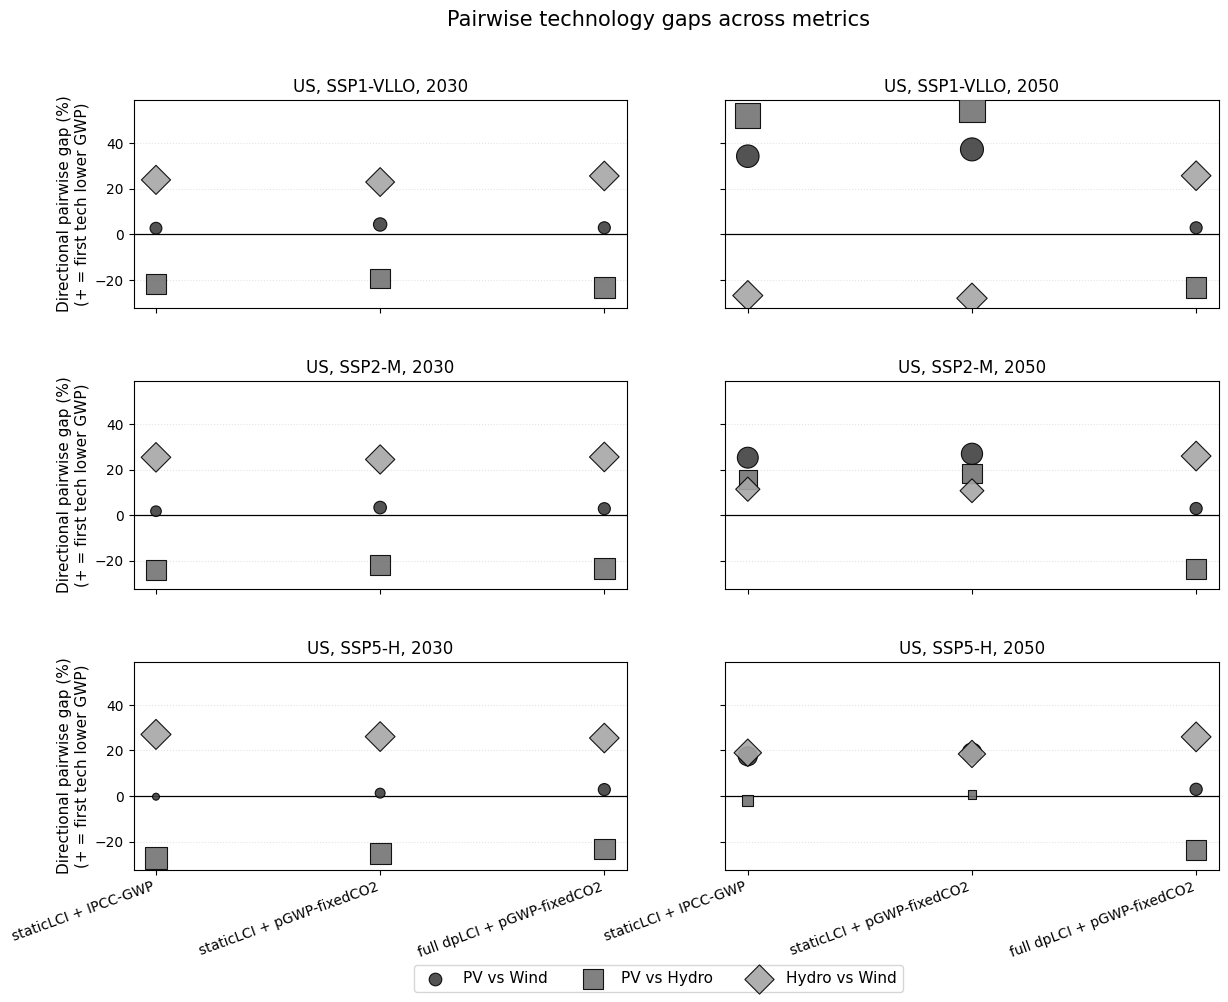

In [40]:
fig, axes = plot_pairwise_gaps_grid_directional(
    df_long=df_full_sorted,
    country="US",
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    years=(2030, 2050),
    metric_order=metric_order,
    metric_labels=metric_labels,
    pairs=(("PV","Wind"), ( "PV", "Hydro"), ("Hydro", "Wind")),

    #directional  = TRUE 
    gap_threshold_pct=5.0,
    figsize=(14, 10),
)
